<a href="https://colab.research.google.com/github/grugg1233/visualization_of_CNN_feature_maps/blob/main/collapsedVsNotCollFeatureVis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# library linking
import torch
import torch.nn as nn
from torchvision.transforms import v2
from torchvision import datasets
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader as Dataloader
from torch.utils.data import Dataset
import torchvision.utils as vutils
import torch.utils.data
import numpy as np
import torch.optim as optim
import random
from collections import defaultdict
import torchvision.transforms as transforms
import os
import torch.nn.functional as F
from google.colab import drive

In [2]:
# hyper parameters and enviornment set up

device = "cuda" if torch.cuda.is_available() else "cpu"
drive.mount('/content/drive')

print(device)
global_bs = 32
global_epochs = 50
global_dropout = 0.2

# collapsed model

c_wd = 2e-4
c_lr = 0.01


# not collapsed

nc_wd = 0.0
nc_lr = 0.01



Mounted at /content/drive
cuda


In [3]:
# rotate cifar examples class

class RotateCIFAR10(Dataset):
  def __init__(self, base_dataset):
    self.base_dataset = base_dataset
    self.rotations = [0,90,180,270]

  def __len__(self):
    return len(self.base_dataset)*4

  def __getitem__(self, idx):
    org_idx = idx // 4
    rot_idx = idx % 4



    img, _ = self.base_dataset[org_idx]
    angle  = self.rotations[rot_idx]
    if int(angle) != 0:
      rot_img = v2.functional.rotate(img, angle)
    else:
      rot_img = img

    return rot_img, rot_idx


In [4]:
# dataset loading and configuration

# CIFAR-10

transform = v2.Compose(
    [v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = Dataloader(train_set, batch_size=global_bs, shuffle=True, num_workers=2)

test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = Dataloader(test_set, batch_size=global_bs, shuffle=False, num_workers=2)

# Rotated Examples

rotated_train_set = RotateCIFAR10(train_set)
rotated_train_loader = Dataloader(rotated_train_set, batch_size=global_bs, shuffle=True, num_workers=2)



100%|██████████| 170M/170M [00:06<00:00, 25.9MB/s]


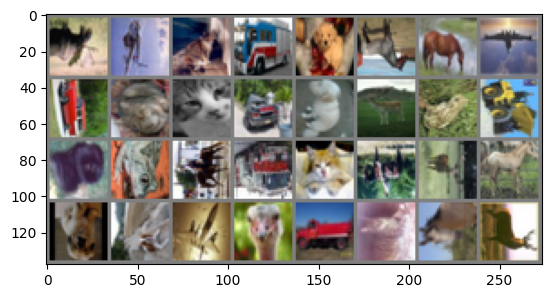

torch.Size([32])
0deg


In [5]:
# display examples from rotated images to verify functionality

def showimage(img):
  img = img / 2 + 0.5
  imgnp = img.numpy()
  plt.imshow(np.transpose(imgnp, (1,2,0)))
  plt.show()


dataiter = iter(rotated_train_loader)
images, labels = next(dataiter)

showimage(vutils.make_grid(images))
print(labels.shape)
classes = ["0deg", "90deg", "180deg", "270deg"]

print(classes[int(labels[4])])


In [6]:
# Architecture - Basic CNN

class ConvNet(nn.Module):
  def __init__(self):
    super().__init__()
    # pooling / unpooling
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)
    self.unpool = nn.MaxUnpool2d(kernel_size=2, stride=2)

    # Network
    self.conv1 = nn.Conv2d(3, 96, 3, 1, 1)
    self.bn1   = nn.BatchNorm2d(96)

    self.conv2 = nn.Conv2d(96, 96, 3, 1, 1)
    self.bn2   = nn.BatchNorm2d(96)

    self.conv3 = nn.Conv2d(96, 96, 3, 1, 1)
    self.bn3   = nn.BatchNorm2d(96)

    self.conv4 = nn.Conv2d(96, 192, 3, 1, 1)
    self.bn4   = nn.BatchNorm2d(192)

    self.conv5 = nn.Conv2d(192, 192, 3, 1, 1)
    self.bn5   = nn.BatchNorm2d(192)

    self.conv6 = nn.Conv2d(192, 192, 3, 1, 1)
    self.bn6   = nn.BatchNorm2d(192)

    self.conv7 = nn.Conv2d(192, 384, 3, 1, 1)
    self.bn7   = nn.BatchNorm2d(384)

    self.conv8 = nn.Conv2d(384, 512, 3, 1, 1)
    self.bn8   = nn.BatchNorm2d(512)

    self.conv9 = nn.Conv2d(512, 512, 3, 1, 1)
    self.bn9   = nn.BatchNorm2d(512)

    # compute output channels

    with torch.no_grad():
      dummy = torch.zeros(1,3,32,32)

      x = F.relu(self.bn1(self.conv1(dummy)))
      x = F.relu(self.bn2(self.conv2(x)))
      x = F.relu(self.bn3(self.conv3(x)))
      x, _ = self.pool(x)

      x = F.relu(self.bn4(self.conv4(x)))
      x = F.relu(self.bn5(self.conv5(x)))
      x = F.relu(self.bn6(self.conv6(x)))
      x, _ = self.pool(x)

      x = F.relu(self.bn7(self.conv7(x)))
      x = F.relu(self.bn8(self.conv8(x)))
      x = F.relu(self.bn9(self.conv9(x)))

      n_channels = x.numel()


    # Fully connected head
    fc1_out = n_channels // 2
    fc2_out = fc1_out // 2

    self.fc1 = nn.Linear(n_channels, fc1_out)
    self.fc2 = nn.Linear(fc1_out, fc2_out)
    self.fc3 = nn.Linear(fc2_out, 512)
    self.classifier = nn.Linear(in_features=512, out_features=4)


  def forward(self, x, save_deconv=False):
    x = F.relu(self.bn1(self.conv1(x)))
    if save_deconv:
        self.act1 = x.detach()
        self.size1 = x.size()

    x = F.relu(self.bn2(self.conv2(x)))
    if save_deconv:
        self.act2 = x.detach()
        self.size2 = x.size()

    x = F.relu(self.bn3(self.conv3(x)))
    if save_deconv:
        self.act3 = x.detach()
        self.size3 = x.size()

    x, idx1 = self.pool(x)

    x = F.relu(self.bn4(self.conv4(x)))
    if save_deconv:
        self.idx1 = idx1
        self.act4 = x.detach()
        self.size4 = x.size()

    x = F.relu(self.bn5(self.conv5(x)))
    if save_deconv:
        self.act5 = x.detach()
        self.size5 = x.size()

    x = F.relu(self.bn6(self.conv6(x)))
    if save_deconv:
        self.act6 = x.detach()
        self.size6 = x.size()

    x, idx2 = self.pool(x)

    x = F.relu(self.bn7(self.conv7(x)))
    if save_deconv:
        self.idx2 = idx2
        self.act7 = x.detach()
        self.size7 = x.size()

    x = F.relu(self.bn8(self.conv8(x)))
    if save_deconv:
        self.act8 = x.detach()
        self.size8 = x.size()

    x = F.relu(self.bn9(self.conv9(x)))
    if save_deconv:
        self.act9 = x.detach()
        self.size9 = x.size()

    x = torch.flatten(x,1)

    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = F.relu(self.fc3(x))
    x = self.classifier(x)

    return x

  def keep_channel(self, act, k):
      z = torch.zeros_like(act)
      z[:, k:k+1, :, :] = act[:, k:k+1, :, :]
      return z

  def deconv(self, k, layer):

      if layer == 1:

          z = self.keep_channel(self.act1, k)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv1.weight, padding=1)

      elif layer == 2:

          z = self.keep_channel(self.act2, k)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv2.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv1.weight, padding=1)

      elif layer == 3:

          z = self.keep_channel(self.act3, k)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv3.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv2.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv1.weight, padding=1)

      elif layer == 4:

          z = self.keep_channel(self.act4, k)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv4.weight, padding=1)

          z = F.relu(z)
          z = self.unpool(
              z,
              self.idx1,
              output_size=self.size3
          )

          z = F.conv_transpose2d(z, self.conv3.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv2.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv1.weight, padding=1)

      elif layer == 5:

          z = self.keep_channel(self.act5, k)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv5.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv4.weight, padding=1)

          z = F.relu(z)
          z = self.unpool(
              z,
              self.idx1,
              output_size=self.size3
          )

          z = F.conv_transpose2d(z, self.conv3.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv2.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv1.weight, padding=1)

      elif layer == 6:

          z = self.keep_channel(self.act6, k)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv6.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv5.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv4.weight, padding=1)

          z = F.relu(z)
          z = self.unpool(
              z,
              self.idx1,
              output_size=self.size3
          )

          z = F.conv_transpose2d(z, self.conv3.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv2.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv1.weight, padding=1)

      elif layer == 7:

          z = self.keep_channel(self.act7, k)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv7.weight, padding=1)

          z = F.relu(z)
          z = self.unpool(
              z,
              self.idx2,
              output_size=self.size6
          )

          z = F.conv_transpose2d(z, self.conv6.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv5.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv4.weight, padding=1)

          z = F.relu(z)
          z = self.unpool(
              z,
              self.idx1,
              output_size=self.size3
          )

          z = F.conv_transpose2d(z, self.conv3.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv2.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv1.weight, padding=1)

      elif layer == 8:

          z = self.keep_channel(self.act8, k)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv8.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv7.weight, padding=1)

          z = F.relu(z)
          z = self.unpool(
              z,
              self.idx2,
              output_size=self.size6
          )

          z = F.conv_transpose2d(z, self.conv6.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv5.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv4.weight, padding=1)

          z = F.relu(z)
          z = self.unpool(
              z,
              self.idx1,
              output_size=self.size3
          )

          z = F.conv_transpose2d(z, self.conv3.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv2.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv1.weight, padding=1)

      elif layer == 9:

          z = self.keep_channel(self.act9, k)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv9.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv8.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv7.weight, padding=1)

          z = F.relu(z)
          z = self.unpool(
              z,
              self.idx2,
              output_size=self.size6
          )

          z = F.conv_transpose2d(z, self.conv6.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv5.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv4.weight, padding=1)

          z = F.relu(z)
          z = self.unpool(
              z,
              self.idx1,
              output_size=self.size3
          )

          z = F.conv_transpose2d(z, self.conv3.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv2.weight, padding=1)

          z = F.relu(z)
          z = F.conv_transpose2d(z, self.conv1.weight, padding=1)

      else:
          raise ValueError("Layer is invalid")

      return z


In [7]:

def trainLoop(wd, lr, model, outPath, lossType="ce"):
  local_out = outPath
  drive_out = f"/content/drive/MyDrive/representationLearning/models/{outPath}"

  for path in [local_out, drive_out]:
      os.makedirs(path, exist_ok=True)
  if lossType.lower() == "mse":
    criterion = nn.MSELoss()
  else:
    criterion = nn.CrossEntropyLoss()

  optimizer = optim.SGD(model.parameters(), lr=lr ,momentum=0.9, weight_decay=wd)

  model.train()
  for epoch in range(global_epochs):
    running_trainLoss = 0.0
    for i, data in enumerate(rotated_train_loader, 0):
      img, true_angle = data[0].to(device), data[1].to(device)

      if lossType.lower() == "mse":
        true_angle = F.one_hot(
            true_angle,
            4
        ).float()

      optimizer.zero_grad()
      pred_angle = model(img)

      loss = criterion(input=pred_angle, target=true_angle)
      loss.backward()
      optimizer.step()

      running_trainLoss += loss.item()

      if (i+1) % 2000 == 0:
        print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_trainLoss / 2000:.3f}')
        running_trainLoss = 0.0


    if (epoch+1) % 5 == 0:
        filename = f"epoch_{epoch+1}.pt"

        torch.save(
            model.state_dict(),
            os.path.join(local_out, filename)
        )

        torch.save(
            model.state_dict(),
            os.path.join(drive_out, filename)
        )

  print("finished training")



In [12]:
def nc1regtrainLoop(wd, lr, model, outPath , penalties: dict | None = None, lossType="ce"):
  # hook penalty layers

  if penalties is not None:
    feats = {}
    layersWithPen = list(penalties.keys())
    for name, module in model.named_modules():
      if name in layersWithPen:
        # register a foward hook to the output of every layer - convolutional and linear
        module.register_forward_hook(
            lambda module, input, output , name=name: feats.__setitem__(name, output)
            )

  # model / optimization initialization and directory management
  local_out = outPath
  drive_out = f"/content/drive/MyDrive/representationLearning/models/{outPath}"

  for path in [local_out, drive_out]:
    os.makedirs(path, exist_ok=True)
  if lossType.lower() == "mse":
    criterion = nn.MSELoss()
  else:
    criterion = nn.CrossEntropyLoss()

  optimizer = optim.SGD(model.parameters(), lr=lr ,momentum=0.9, weight_decay=wd)

  model.train()
  for epoch in range(global_epochs):

    running_train_loss = 0.0

    for iteration, data in enumerate(rotated_train_loader, 0):

      img_batch, true_labels = data[0].to(device), data[1].to(device) # label : [B, 1] - so for MSE we will want to one hot encode so that it is [B, numClasses]

      optimizer.zero_grad()

      modelPred = model(img_batch)

      if lossType.lower() == "mse":
        loss_targets = F.one_hot(
            true_labels,
            4
        ).float()
      else:
        loss_targets = true_labels
      loss = criterion(input=modelPred, target=loss_targets)


      if penalties is not None:

        for layer in feats.keys():
          if epoch == 0 and iteration == 0:
            print(f"regularized layer : {layer} in epoch: {epoch + 1}")
          eps = 1e-6
          z = feats.get(layer, None)
          if z is None:
            continue

          # if the layer is a convolutional one reshape it using GAP
          if z.dim() == 4:
            z = z.mean(dim=(2,3))

          B, D = z.shape # batch , size_of_feature

          counts = torch.bincount(true_labels, minlength=4).float()
          sums = z.new_zeros(4, D)
          sums.index_add_(0, true_labels, z)
          means = sums / counts.clamp_min(1.0).unsqueeze(1) # (4, D)

          # batch-wise class means

          mu_y =  means.index_select(0, true_labels)
          trace_sw = ((z - mu_y) ** 2).sum() / float(B)

          # batch - global mean
          mu = z.mean(0) # because this will effectively compute a mean vector shaped (D, ) that will be the average over all features in the batch for layer l
          diff = means - mu.unsqueeze(0) # using broadcasting to get a (C, D) tensor that holds the difference between an examples (mu_c) and the global mean (mu_G) for batch b in layer l
          trace_sb = (counts.unsqueeze(1) * ((diff)**2)).sum() / float(B)
          nc1 = trace_sw / (trace_sb.detach() + eps)
          penalty = -1 * (torch.log(nc1 + eps))
          w = penalties.get(layer, 0)
          loss = loss + w * penalty

      loss.backward()
      optimizer.step()

      running_train_loss += loss.item()

      if (iteration + 1) % 2000 == 0:
        print(f"epoch : {epoch + 1} images: {(iteration + 1):5d}, train loss: {(running_train_loss / 2000.0):0.4f}")
        running_train_loss = 0.0
    if (epoch+1) % 5 == 0:
        filename = f"epoch_{epoch+1}.pt"

        torch.save(
            model.state_dict(),
            os.path.join(local_out, filename)
        )

        torch.save(
            model.state_dict(),
            os.path.join(drive_out, filename)
        )

In [ ]:
# collpased
collnet = ConvNet().to(device)

trainLoop(c_wd,c_lr,model=collnet, outPath="collapsedBackbone", lossType="mse")

In [14]:
#Not Collapsed

notcollnet = ConvNet().to(device)

p = {}

maxPen = 5e-3
counter = 0
for name , module in notcollnet.named_modules():
  if isinstance(module, nn.Conv2d):
    if (counter+1) % 3 == 0:
      maxPen = maxPen * 2
    p[name] = maxPen
    counter += 1

if hasattr(notcollnet, "lin1"):
  p["lin1"] = 1e-3
if hasattr(notcollnet, "lin2"):
  p["lin2"] = 1e-3
if hasattr(notcollnet, "lin3"):
  p["lin3"] = 1e-3
if hasattr(notcollnet, "classifier"):
  p["classifier"] = 5e-4



nc1regtrainLoop(nc_wd,nc_lr,model=notcollnet, outPath="notCollapsedBackbone", lossType="mse", penalties=p)

regularized layer : conv1 in epoch: 1
regularized layer : conv2 in epoch: 1
regularized layer : conv3 in epoch: 1
regularized layer : conv4 in epoch: 1
regularized layer : conv5 in epoch: 1
regularized layer : conv6 in epoch: 1
regularized layer : conv7 in epoch: 1
regularized layer : conv8 in epoch: 1
regularized layer : conv9 in epoch: 1
regularized layer : classifier in epoch: 1
epoch : 1 images:  2000, train loss: -0.1830
epoch : 1 images:  4000, train loss: -0.1927
epoch : 1 images:  6000, train loss: -0.1996
epoch : 2 images:  2000, train loss: -0.2102
epoch : 2 images:  4000, train loss: -0.2097
epoch : 2 images:  6000, train loss: -0.2110
epoch : 3 images:  2000, train loss: -0.2147
epoch : 3 images:  4000, train loss: -0.2100
epoch : 3 images:  6000, train loss: -0.2117
epoch : 4 images:  2000, train loss: -0.2143
epoch : 4 images:  4000, train loss: -0.2136
epoch : 4 images:  6000, train loss: -0.2181
epoch : 5 images:  2000, train loss: -0.2206
epoch : 5 images:  4000, train

In [15]:
# Neural Collapse Measurements

# Neural Collapse Measurements
# NC - 3 Metric

def compute_nc3(model, M_dot):

  W = model.classifier.weight.detach()

  W_fro = torch.linalg.norm(W, ord="fro")

  M_dot_fro = torch.linalg.norm(M_dot, ord="fro")

  W_T = W.T

  W_norm = W_T / (W_fro + 1e-8)

  M_norm = M_dot / (M_dot_fro + 1e-8)

  dif = W_norm - M_norm

  nc3 = torch.linalg.norm(dif, ord="fro")

  return nc3


# NC - 1 : as training progresses the within class variation of the activations becomes negligible

  # measure 1-
  # (layerwise per epoch covariances post ReLU) i.e. act1 = relu(conv1(x)).detach() save
  # this activation and measure tr(Ew) / tr(Eb) against epoch
  # measure 2 -
  # layers against tr(Ew) / tr(Eb)

def computeMu_G(model, features, hook_name):
    print(f"computeMu_G {hook_name}", flush=True)
    dummy_input = torch.randn(1, 3, 32, 32).to(device)
    with torch.no_grad():
        _ = model(dummy_input)
    num_channels = features[hook_name].size(1)
    layer_mean = torch.zeros(num_channels, device=device)

    total_examples = 0
    with torch.no_grad():
      for data in rotated_train_loader:
        img, true_rot = data[0].to(device), data[1].to(device)
        _ = model(img)
        z = features[hook_name].detach()

        if z.dim() == 4:
            gap_z = z.mean(dim=[2,3])
        else:
            gap_z = z
        batch_sum = torch.sum(gap_z, dim=0)

        layer_mean += batch_sum
        total_examples += img.size(0)


    layer_mean = layer_mean / total_examples
    return layer_mean

def computeMu_C(model, features, hook_name):
    print(f"computeMu_C {hook_name}", flush=True)
    dummy_input = torch.randn(1, 3, 32, 32).to(device)
    with torch.no_grad():
        _ = model(dummy_input)
    num_channels = features[hook_name].size(1)
    layer_means = [torch.zeros(num_channels, device=device) for _ in range(4)]
    class_counts = [0,0,0,0]
    total_examples = 0
    with torch.no_grad():
      for data in rotated_train_loader:
        img_batch, true_rot = data[0].to(device), data[1].to(device)

        # true_rot - 32 indecies in range 0,1,2,3
        _ = model(img_batch)

        # feature
        z = features[hook_name].detach()
        if z.dim() == 4:
            gap_z = z.mean(dim=[2,3])
        else:
            gap_z = z

        for idx in range(img_batch.size(0)):
          individualFeature = gap_z[idx]
          label = true_rot[idx].item()

          layer_means[label] += individualFeature
          class_counts[label] += 1


    for i in range(4):
      if class_counts[i] > 0:
        layer_means[i] = layer_means[i] / class_counts[i]

    return layer_means

def compute_sigB(num_classes, mu_G, mu_C, hook):
  print(f"compute_sigB {hook}", flush=True)
  sigB = torch.zeros((mu_C[0][hook].size(0),mu_C[0][hook].size(0)), device=mu_G[hook].device)
  for i in range(num_classes):
    dif = mu_C[i][hook] - mu_G[hook]
    sigB += torch.outer(dif, dif)
  return (1 / num_classes) * sigB

def compute_sigW(mu_C, hook, model, features):
  print(f"compute_sigW {hook}", flush=True)
  sigW = torch.zeros((mu_C[0][hook].size(0), mu_C[0][hook].size(0)), device=mu_C[0][hook].device)

  with torch.no_grad():
    total = 0
    for data in rotated_train_loader:

      imgs, true_rot = data[0].to(device), data[1].to(device)

      _ = model(imgs)

      z = features[hook].detach()
      if z.dim() == 4:
          gap_z = z.mean(dim=[2,3])
      else:
          gap_z = z

      for idx in range(imgs.size(0)):
        ind_feat = gap_z[idx]
        label = true_rot[idx].item()
        dif = ind_feat - mu_C[label][hook]
        sigW += torch.outer(dif, dif)
        total += 1

    return (1 / total) * sigW.detach()

def computeNC(model, num_classes):
  print("Computing NC1... ")
  criterion = nn.CrossEntropyLoss()

  # global feature map = { layer : features post activation }
  features = {}
  hook_handles = []

  # feature hook - post activation - we will be measuring the covariance (spread) around the class means
  def get_activation(name, apply_relu=False):
    def hook(model, input, output):
      detached_out = output.detach()
      if apply_relu:
        features[name] = torch.relu(detached_out)
      else:
        features[name] = detached_out
    return hook

  bn_counter = 1
  hook_names_list = []

  for name, module in model.named_modules():

    if isinstance(module, nn.BatchNorm2d):
      hook_name = f'bn{bn_counter}'

      handle = module.register_forward_hook(get_activation(hook_name, apply_relu=True))
      hook_handles.append(handle)
      hook_names_list.append(hook_name)
      print(f"Hooking {name} \n")
      bn_counter += 1



  # if hasattr(model, 'fc1'):
  #     handle = model.fc1.register_forward_hook(get_activation('fc1', apply_relu=True))
  #     hook_handles.append(handle)
  #     hook_names_list.append('fc1')
  #     print(f"Hooking fc1 \n")

  # if hasattr(model, 'fc2'):
  #     handle = model.fc2.register_forward_hook(get_activation('fc2', apply_relu=True))
  #     hook_handles.append(handle)
  #     hook_names_list.append('fc2')
  #     print(f"Hooking fc2 \n")

  if hasattr(model, 'fc3'):
      handle = model.fc3.register_forward_hook(get_activation('fc3', apply_relu=True))
      hook_handles.append(handle)
      hook_names_list.append('fc3')
      print(f"Hooking fc3 \n")

  if hasattr(model, 'classifier'):
      handle = model.classifier.register_forward_hook(get_activation('classifier', apply_relu=False))
      hook_handles.append(handle)
      hook_names_list.append('classifier')
      print(f"Hooking classifier \n")

  global_means = {}
  class_means = {0:{}, 1:{}, 2:{}, 3:{}}
  for hook in hook_names_list:
    print(f"Computing means for {hook}")
    layer_mean = computeMu_G(model,features, hook)
    global_means[hook] = layer_mean

    layer_means_perClass = computeMu_C(model, features, hook)
    class_means[0][hook] = layer_means_perClass[0]
    class_means[1][hook] = layer_means_perClass[1]
    class_means[2][hook] = layer_means_perClass[2]
    class_means[3][hook] = layer_means_perClass[3]

  Sig_B = {}
  Sig_W = {}
  NC_1 = {}


  for hook in hook_names_list:

    Sig_B[hook] = compute_sigB(num_classes,global_means,class_means,hook)

    Sig_W[hook] = compute_sigW(class_means, hook, model, features)

    NC_1[hook] = torch.trace(Sig_W[hook]) / (torch.trace(Sig_B[hook]) + 1e-8)



  for handle in hook_handles:
    handle.remove()

  m_dot = torch.zeros((class_means[0]["fc3"].size(0), num_classes), device=device)

  for c in range(num_classes):
    m_dot[:, c] = class_means[c]["fc3"] - global_means["fc3"]

  print("Computing NC3... ")
  nc3 = compute_nc3(model, M_dot=m_dot)

  return NC_1, nc3




def plot_nc1_by_layer(nc1, save_path, modelPath):
  drive_path = (f"/content/drive/MyDrive/representationLearning/models/{save_path}")
  os.makedirs(os.path.dirname(save_path), exist_ok=True)
  os.makedirs(os.path.dirname(drive_path), exist_ok=True)
  x_axis_values = list(nc1.keys())[:-1]
  y_axis_values = [ v.cpu().item() for v in nc1.values() ][:-1]
  x_len = list(range(len(x_axis_values)))
  plt.figure()
  plt.semilogy(x_len, y_axis_values, "bx-")
  plt.xticks(x_len, x_axis_values, rotation=45, ha="right")
  plt.xlabel("layer")
  plt.ylabel("tr(SigW) / tr(SigB)")
  plt.title(f"NC1 - {modelPath.split('.')[0]}")
  plt.tight_layout()
  plt.savefig(save_path)
  plt.savefig(drive_path)
  plt.close()




ModelPATH = "notCollapsedBackbone/epoch_50.pt"
net = ConvNet().to(device)
net.load_state_dict(torch.load(ModelPATH, map_location=device))
net.eval()
nc1, nc3 = computeNC(net, 4)
print(nc3)
print(nc1)
plot_nc1_by_layer(nc1, "graphs/not_collapsed/nc1.pdf", ModelPATH)



Computing NC1... 
Hooking bn1 

Hooking bn2 

Hooking bn3 

Hooking bn4 

Hooking bn5 

Hooking bn6 

Hooking bn7 

Hooking bn8 

Hooking bn9 

Hooking fc3 

Hooking classifier 

Computing means for bn1
computeMu_G bn1
computeMu_C bn1
Computing means for bn2
computeMu_G bn2
computeMu_C bn2
Computing means for bn3
computeMu_G bn3
computeMu_C bn3
Computing means for bn4
computeMu_G bn4
computeMu_C bn4
Computing means for bn5
computeMu_G bn5
computeMu_C bn5
Computing means for bn6
computeMu_G bn6
computeMu_C bn6
Computing means for bn7
computeMu_G bn7
computeMu_C bn7
Computing means for bn8
computeMu_G bn8
computeMu_C bn8
Computing means for bn9
computeMu_G bn9
computeMu_C bn9
Computing means for fc3
computeMu_G fc3
computeMu_C fc3
Computing means for classifier
computeMu_G classifier
computeMu_C classifier
compute_sigB bn1
compute_sigW bn1
compute_sigB bn2
compute_sigW bn2
compute_sigB bn3
compute_sigW bn3
compute_sigB bn4
compute_sigW bn4
compute_sigB bn5
compute_sigW bn5
compute_sigB b

In [17]:
# Evaluate the models Performance

# ModelPATH = "collapsedBackbone/epoch_50.pt"
ModelPATH = "notCollapsedBackbone/epoch_50.pt"
net = ConvNet().to(device)
net.load_state_dict(torch.load(ModelPATH, map_location=device))
net.eval()

rotated_test_set = RotateCIFAR10(test_set)
rotated_test_loader = Dataloader(rotated_test_set, batch_size=global_bs, shuffle=False, num_workers=2)

with torch.no_grad():
  total_correct = 0.0
  examples_seen = 0.0

  for data in rotated_test_loader:
    img, label = data[0].to(device), data[1].to(device)
    pred = net(img)
    pred_labels = pred.argmax(dim=1)
    for idx in range(img.size(0)):
      total_correct += (pred_labels[idx] == label[idx]).item()
      examples_seen += 1.0

overall_accuracy = 100 * (total_correct / examples_seen)
print(f"Test Accuracy: {overall_accuracy:.2f}%")



with torch.no_grad():
  total_correct = 0.0
  examples_seen = 0.0

  for data in rotated_train_loader:
    img, label = data[0].to(device), data[1].to(device)
    pred = net(img)
    pred_labels = pred.argmax(dim=1)
    for idx in range(img.size(0)):
      total_correct += (pred_labels[idx] == label[idx]).item()
      examples_seen += 1.0

overall_accuracy = 100 * (total_correct / examples_seen)
print(f"Train Accuracy: {overall_accuracy:.2f}%")

Test Accuracy: 67.25%
Train Accuracy: 98.74%



Class: 0deg


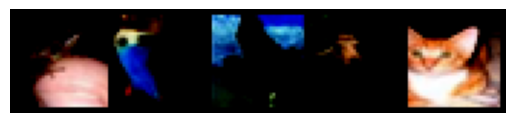

Layer 1 representations:


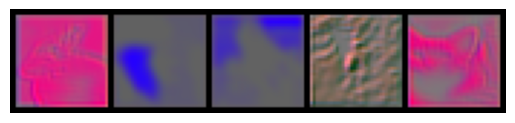

Layer 2 representations:


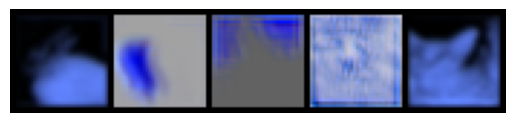

Layer 3 representations:


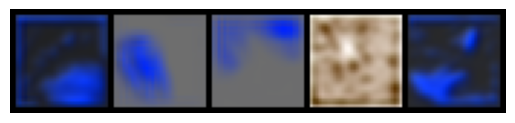

Layer 4 representations:


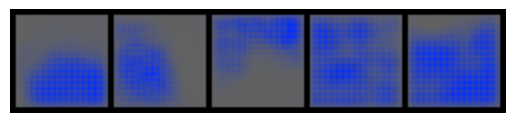

Layer 5 representations:


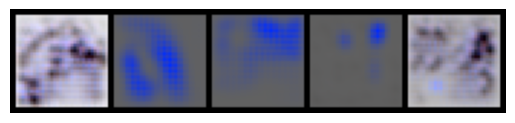

Layer 6 representations:


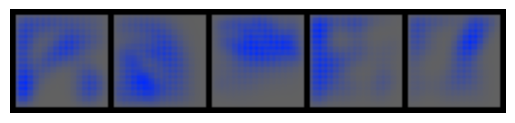

Layer 7 representations:


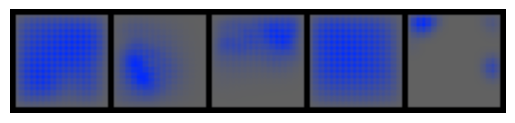

Layer 8 representations:


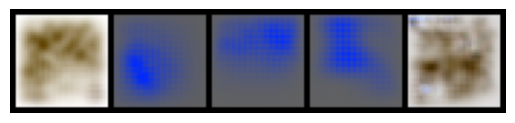

Layer 9 representations:


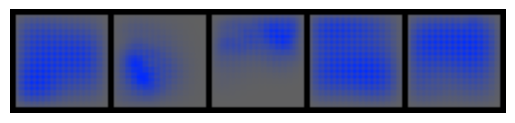


Class: 90deg


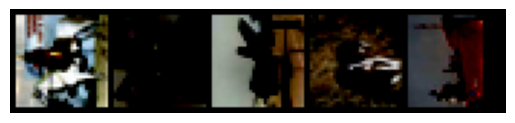

Layer 1 representations:


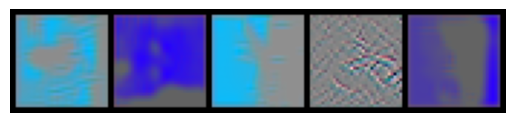

Layer 2 representations:


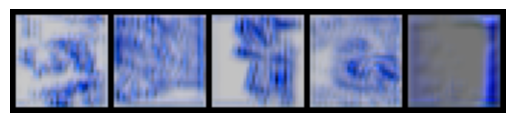

Layer 3 representations:


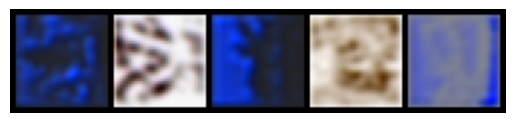

Layer 4 representations:


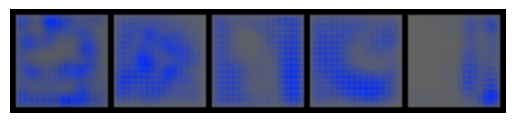

Layer 5 representations:


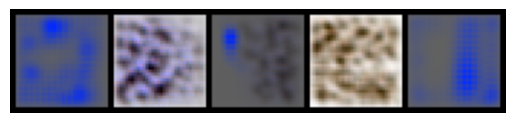

Layer 6 representations:


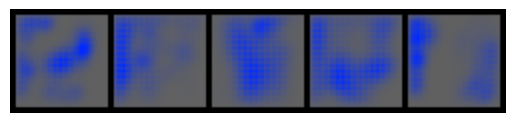

Layer 7 representations:


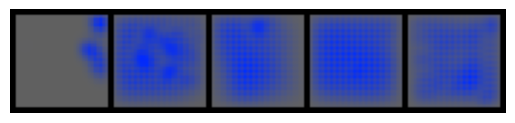

Layer 8 representations:


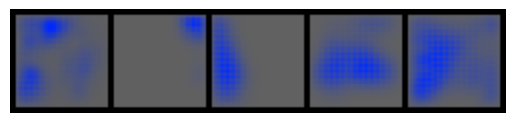

Layer 9 representations:


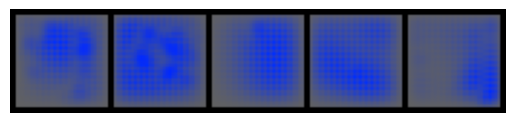


Class: 180deg


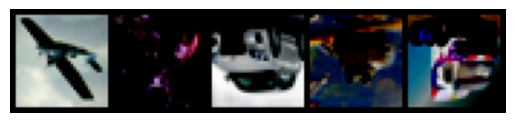

Layer 1 representations:


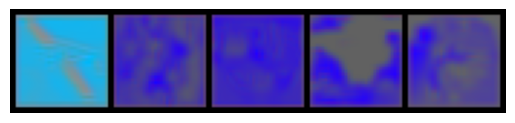

Layer 2 representations:


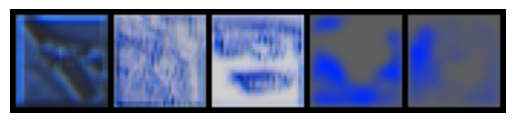

Layer 3 representations:


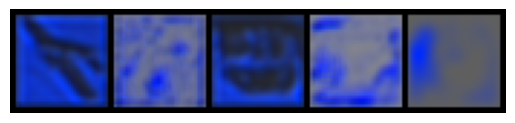

Layer 4 representations:


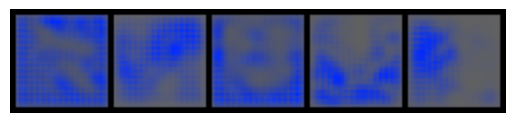

Layer 5 representations:


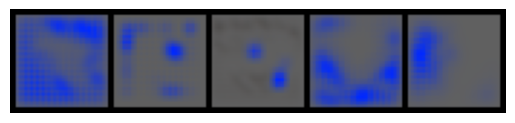

Layer 6 representations:


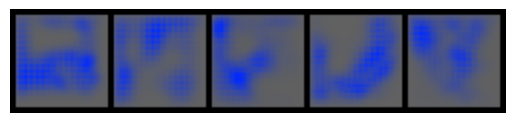

Layer 7 representations:


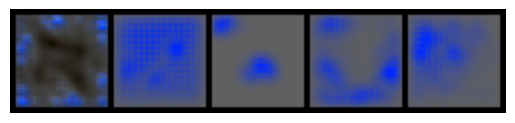

Layer 8 representations:


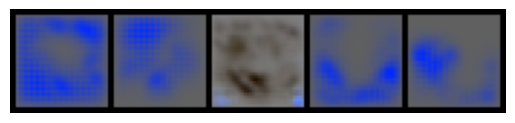

Layer 9 representations:


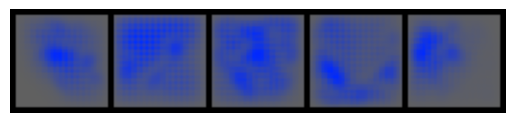


Class: 270deg


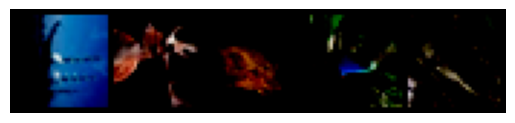

Layer 1 representations:


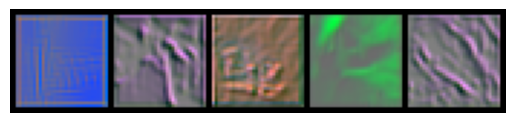

Layer 2 representations:


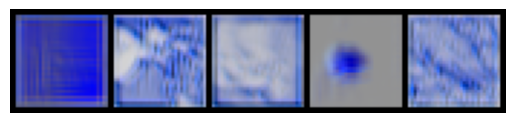

Layer 3 representations:


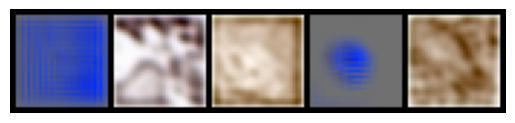

Layer 4 representations:


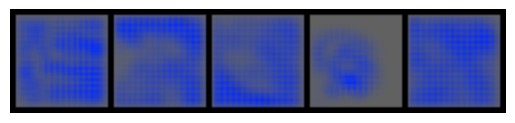

Layer 5 representations:


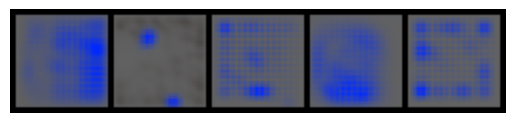

Layer 6 representations:


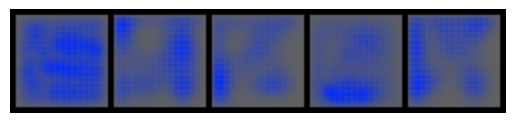

Layer 7 representations:


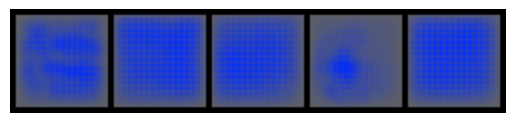

Layer 8 representations:


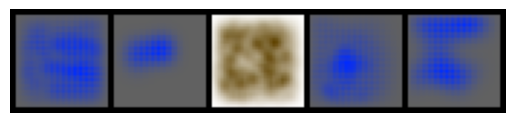

Layer 9 representations:


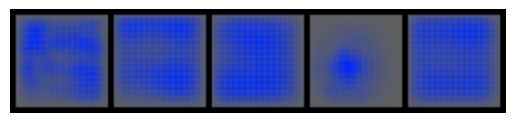

In [18]:
# Visualization of Layers in the model

DRIVE_SAVE_PATH = f"/content/drive/MyDrive/representationLearning/models/graphs/featureVisualizations/notCollapsed/"

def showImage(img, saveToPath, show=False, denorm=False):
    os.makedirs(os.path.dirname(saveToPath), exist_ok=True)

    if denorm:
        img = img / 2 + 0.5

    npimg = img.detach().cpu().numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")
    plt.savefig(saveToPath, bbox_inches="tight", pad_inches=0)

    if show:
        plt.show()

    plt.close()


# ModelPATH = "collapsedBackbone/epoch_50.pt"

ModelPATH = "notCollapsedBackbone/epoch_50.pt"
net = ConvNet().to(device)
net.load_state_dict(torch.load(ModelPATH, map_location=device))
net.eval()

# Build class -> images mapping
class_examples = defaultdict(list)


for images, labels in rotated_test_loader:
    for img, label in zip(images, labels):
        class_examples[int(label.item())].append(img)

def normalize_recon(recon):
    recon = recon.squeeze(0).cpu()
    recon = recon - recon.min()
    recon = recon / (recon.max() + 1e-8)
    return recon


def best_channel_for_layer(act):
    channel_energy = act[0].abs().sum(dim=(1, 2))
    return int(channel_energy.argmax().item())


def visualize_k_per_class():
    for class_id, class_name in enumerate(classes):
        samples = random.sample(class_examples[class_id], k=5)

        print(f"\nClass: {class_name}")

        showImage(
            vutils.make_grid(samples, nrow=5),
            f"{DRIVE_SAVE_PATH}/{class_name}_originals.pdf",
            True
        )

        featureVis1 = []
        featureVis2 = []
        featureVis3 = []
        featureVis4 = []
        featureVis5 = []
        featureVis6 = []
        featureVis7 = []
        featureVis8 = []
        featureVis9 = []

        with torch.no_grad():
            for img in samples:
                image = img.to(device).unsqueeze(0)

                _ = net(image, save_deconv=True)

                k1 = best_channel_for_layer(net.act1)
                recon1 = net.deconv(k=k1, layer=1)
                featureVis1.append(normalize_recon(recon1))

                k2 = best_channel_for_layer(net.act2)
                recon2 = net.deconv(k=k2, layer=2)
                featureVis2.append(normalize_recon(recon2))

                k3 = best_channel_for_layer(net.act3)
                recon3 = net.deconv(k=k3, layer=3)
                featureVis3.append(normalize_recon(recon3))

                k4 = best_channel_for_layer(net.act4)
                recon4 = net.deconv(k=k4, layer=4)
                featureVis4.append(normalize_recon(recon4))

                k5 = best_channel_for_layer(net.act5)
                recon5 = net.deconv(k=k5, layer=5)
                featureVis5.append(normalize_recon(recon5))

                k6 = best_channel_for_layer(net.act6)
                recon6 = net.deconv(k=k6, layer=6)
                featureVis6.append(normalize_recon(recon6))

                k7 = best_channel_for_layer(net.act7)
                recon7 = net.deconv(k=k7, layer=7)
                featureVis7.append(normalize_recon(recon7))

                k8 = best_channel_for_layer(net.act8)
                recon8 = net.deconv(k=k8, layer=8)
                featureVis8.append(normalize_recon(recon8))

                k9 = best_channel_for_layer(net.act9)
                recon9 = net.deconv(k=k9, layer=9)
                featureVis9.append(normalize_recon(recon9))


        for layer_idx, featureVis in enumerate(
            [featureVis1, featureVis2, featureVis3, featureVis4, featureVis5,
            featureVis6, featureVis7, featureVis8, featureVis9],
            start=1
        ):
            print(f"Layer {layer_idx} representations:")
            save_path = f"{DRIVE_SAVE_PATH}/conv{layer_idx}/{class_name}.pdf"
            showImage(vutils.make_grid(featureVis, nrow=5), save_path, show=True)

visualize_k_per_class()